# Student Dropout Prediction — Initial EDA

This notebook loads the dataset and performs initial inspection before preprocessing, binary target setup, and feature selection.

## Import Library

In [39]:
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Check and Load Data

### Check Path and Dataset Existence

In [40]:
PROJECT_ROOT = Path.cwd().parent
DATA_PATH = PROJECT_ROOT / "data" / "raw" / "dataset.csv"

print("Project root:", PROJECT_ROOT)
print("Dataset path:", DATA_PATH)
print("Dataset exists:", DATA_PATH.exists())

Project root: c:\not_default\Projects\student-dropout-prediction-ml
Dataset path: c:\not_default\Projects\student-dropout-prediction-ml\data\raw\dataset.csv
Dataset exists: True


### Load Dataset

In [41]:
df = pd.read_csv(DATA_PATH)

print("Dataset loaded successfully.")
print("Shape:", df.shape)

df.head()

Dataset loaded successfully.
Shape: (4424, 35)


,Marital status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Nacionality,Mother's qualification,Father's qualification,Mother's occupation,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,8,5,2,1,1,1,13,10,6,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,6,1,11,1,1,1,1,3,4,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,5,1,1,1,22,27,10,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,8,2,15,1,1,1,23,27,6,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,12,1,3,0,1,1,22,28,10,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


## EDA

### Dataset Info

In [42]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 35 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   Marital status                                  4424 non-null   int64  
 1   Application mode                                4424 non-null   int64  
 2   Application order                               4424 non-null   int64  
 3   Course                                          4424 non-null   int64  
 4   Daytime/evening attendance                      4424 non-null   int64  
 5   Previous qualification                          4424 non-null   int64  
 6   Nacionality                                     4424 non-null   int64  
 7   Mother's qualification                          4424 non-null   int64  
 8   Father's qualification                          4424 non-null   int64  
 9   Mother's occupation                             4424

### Check Column List

In [43]:
df.columns.tolist()

['Marital status',
 'Application mode',
 'Application order',
 'Course',
 'Daytime/evening attendance',
 'Previous qualification',
 'Nacionality',
 "Mother's qualification",
 "Father's qualification",
 "Mother's occupation",
 "Father's occupation",
 'Displaced',
 'Educational special needs',
 'Debtor',
 'Tuition fees up to date',
 'Gender',
 'Scholarship holder',
 'Age at enrollment',
 'International',
 'Curricular units 1st sem (credited)',
 'Curricular units 1st sem (enrolled)',
 'Curricular units 1st sem (evaluations)',
 'Curricular units 1st sem (approved)',
 'Curricular units 1st sem (grade)',
 'Curricular units 1st sem (without evaluations)',
 'Curricular units 2nd sem (credited)',
 'Curricular units 2nd sem (enrolled)',
 'Curricular units 2nd sem (evaluations)',
 'Curricular units 2nd sem (approved)',
 'Curricular units 2nd sem (grade)',
 'Curricular units 2nd sem (without evaluations)',
 'Unemployment rate',
 'Inflation rate',
 'GDP',
 'Target']

### Check Duplicate Rows

In [44]:
duplicate_count = df.duplicated().sum()

print("Duplicate rows:", duplicate_count)

Duplicate rows: 0


### Check Missing Values

In [45]:
missing_values = df.isnull().sum().sort_values(ascending=False)

missing_values[missing_values > 0]

Series([], dtype: int64)

### Binary Target Setup

The original target contains three classes: Dropout, Enrolled, and Graduate.  
For this project, the task is converted into binary classification by removing Enrolled records and mapping:

- Dropout = 1
- Graduate = 0

In [46]:
df_binary = df[df["Target"] != "Enrolled"].copy()

print("Original shape:", df.shape)
print("Binary dataset shape:", df_binary.shape)
print("Removed Enrolled rows:", df.shape[0] - df_binary.shape[0])

Original shape: (4424, 35)
Binary dataset shape: (3630, 35)
Removed Enrolled rows: 794


### Target Distribution Visualization
This section visualizes the distribution of the original target classes to understand class imbalance before preprocessing.

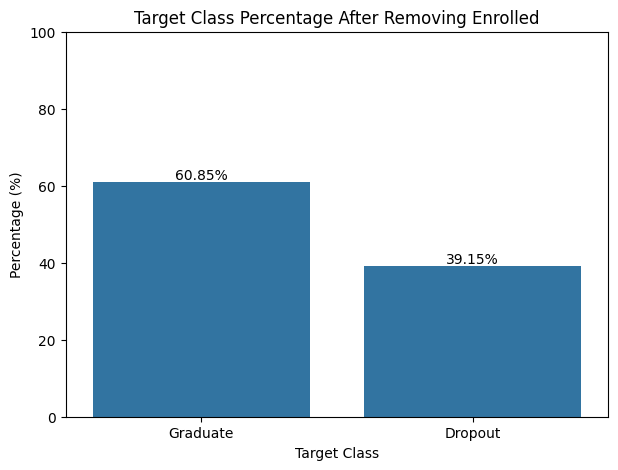

In [47]:
plt.figure(figsize=(7, 5))

ax = sns.barplot(
    x=target_percentage.index,
    y=target_percentage.values
)

plt.title("Target Class Percentage After Removing Enrolled")
plt.xlabel("Target Class")
plt.ylabel("Percentage (%)")
plt.ylim(0, 100)

for container in ax.containers:
    ax.bar_label(container, fmt="%.2f%%")

plt.show()